# SaaS Product Analytics & Churn Prediction

## 08 — Model Explainability

### Objective

Explain the predictions generated by the churn prediction model.

The previous notebook answered:

> Which customers are likely to churn?

This notebook answers:

> Why does the model believe they are likely to churn?

### Explainability Methods

This notebook uses:

- Global feature importance
- SHAP feature importance
- SHAP summary analysis
- Individual customer explanations
- High-risk customer investigation
- Business interpretation

### Business Objective

A churn prediction model is only useful if business teams can understand and act on its predictions.

The goal is therefore to connect machine-learning predictions with actionable customer behavior.

In [5]:
from pathlib import Path

import warnings
import json
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Project Configuration

In [6]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

ANALYTICS_DIR = (
    PROJECT_ROOT
    / "data"
    / "analytics"
)

MODEL_DIR = (
    PROJECT_ROOT
    / "models"
)

print("Project root:")
print(PROJECT_ROOT)

print("\nAnalytics directory:")
print(ANALYTICS_DIR)

print("\nModel directory:")
print(MODEL_DIR)

Project root:
c:\Users\user\Desktop\Data Analysis Projects\SaaS Product Analytics & Churn Prediction

Analytics directory:
c:\Users\user\Desktop\Data Analysis Projects\SaaS Product Analytics & Churn Prediction\data\analytics

Model directory:
c:\Users\user\Desktop\Data Analysis Projects\SaaS Product Analytics & Churn Prediction\models


## 2. Load the Saved Churn Model

The model was trained in:

`07_Churn_Prediction.ipynb`

We will reuse the saved pipeline instead of retraining the model.

In [7]:
model_path = (
    MODEL_DIR
    / "churn_prediction_model.pkl"
)

if not model_path.exists():

    raise FileNotFoundError(
        f"Model not found: {model_path}\n"
        "Run 07_Churn_Prediction.ipynb first."
    )

model = joblib.load(
    model_path
)

print(
    "Model loaded successfully."
)

print(
    "\nModel type:"
)

print(
    type(model)
)

Model loaded successfully.

Model type:
<class 'sklearn.pipeline.Pipeline'>


## 3. Load Model Metadata

In [8]:
metadata_path = (
    MODEL_DIR
    / "churn_model_metadata.json"
)

if metadata_path.exists():

    with open(
        metadata_path,
        "r",
        encoding="utf-8",
    ) as file:

        metadata = json.load(file)

    display(
        pd.Series(metadata)
    )

else:

    metadata = {}

    print(
        "Model metadata not found."
    )

model                                                    Logistic Regression
observation_window_days                                                   90
prediction_window_days                                                    30
reference_threshold                                                   0.7000
roc_auc                                                               0.8161
pr_auc                                                                0.0279
precision                                                             0.0354
recall                                                                0.2518
f1                                                                    0.0621
features                   [total_events, active_days, active_months, act...
dtype: object

## 4. Load Churn Prediction Dataset

In [9]:
prediction_data_path = (
    ANALYTICS_DIR
    / "churn_prediction_dataset.csv"
)

if not prediction_data_path.exists():

    raise FileNotFoundError(
        f"Prediction dataset not found: "
        f"{prediction_data_path}\n"
        "Run 07_Churn_Prediction.ipynb first."
    )

prediction_data = pd.read_csv(
    prediction_data_path
)

prediction_data[
    "cutoff_date"
] = pd.to_datetime(
    prediction_data[
        "cutoff_date"
    ],
    errors="coerce",
)

print(
    "Prediction dataset shape:",
    prediction_data.shape
)

display(
    prediction_data.head()
)

Prediction dataset shape: (409637, 21)


,user_id,total_events,active_days,active_months,first_activity,last_activity,activity_recency_days,avg_events_per_active_day,cutoff_date,plan,billing_frequency,monthly_recurring_revenue,trial,acquisition_source,tenure_days_at_cutoff,tenure_months_at_cutoff,churn_in_prediction_window,events_per_active_month,events_per_tenure_month,is_recently_active,is_low_engagement
0,U000002,3,3,2,2024-03-10,2024-04-12,19,1.0000,2024-05-01 13:54:32,Free,NaN,0.0000,True,Self-Serve,73,2.3982,0,1.5000,1.2510,0,1
1,U020093,1,1,1,2024-04-15,2024-04-15,16,1.0000,2024-05-01 13:54:32,Starter,Monthly,29.0000,False,Self-Serve,33,1.0841,0,1.0000,0.9224,0,1
2,U020097,1,1,1,2024-04-27,2024-04-27,4,1.0000,2024-05-01 13:54:32,Starter,Monthly,29.0000,True,Self-Serve,10,0.3285,0,1.0000,3.0440,1,1
3,U020103,1,1,1,2024-02-27,2024-02-27,64,1.0000,2024-05-01 13:54:32,Free,NaN,0.0000,True,Self-Serve,81,2.6610,0,1.0000,0.3758,0,1
4,U020135,4,4,2,2024-03-02,2024-04-30,1,1.0000,2024-05-01 13:54:32,Professional,Monthly,79.0000,False,Partner,93,3.0552,0,2.0000,1.3092,1,1


## 5. Load Previously Generated Risk Scores

The risk-score dataset contains the model's predicted churn probability for customers in the test period.

In [10]:
risk_path = (
    ANALYTICS_DIR
    / "churn_risk_scores.csv"
)

if risk_path.exists():

    risk_scores = pd.read_csv(
        risk_path
    )

    risk_scores[
        "cutoff_date"
    ] = pd.to_datetime(
        risk_scores[
            "cutoff_date"
        ],
        errors="coerce",
    )

    print(
        "Risk scores loaded:",
        len(risk_scores)
    )

    display(
        risk_scores.head()
    )

else:

    risk_scores = None

    print(
        "Risk-score file not found."
    )

Risk scores loaded: 146694


,user_id,cutoff_date,plan,billing_frequency,monthly_recurring_revenue,churn_probability,predicted_churn,risk_segment,risk_revenue_score
0,U020047,2026-02-01 13:54:32,Professional,Monthly,79.0000,0.5860,0,High,46.2973
1,U020048,2026-02-01 13:54:32,Free,NaN,0.0000,0.0000,0,Low,0.0000
2,U020049,2026-02-01 13:54:32,Starter,Monthly,29.0000,0.1383,0,Low,4.0116
3,U020046,2026-02-01 13:54:32,Professional,Monthly,79.0000,0.6218,0,High,49.1192
4,U020036,2026-02-01 13:54:32,Free,NaN,0.0000,0.0001,0,Low,0.0000


## 6. Identify the Model Structure

The saved model is a scikit-learn pipeline containing:

1. Preprocessor
2. Machine-learning model

We inspect both components before explaining predictions.

In [11]:
print(
    "Pipeline steps:"
)

for name, step in model.named_steps.items():

    print(
        f"- {name}: {type(step).__name__}"
    )

Pipeline steps:
- preprocessor: ColumnTransformer
- model: LogisticRegression


## 7. Identify the Underlying Model

In [12]:
preprocessor = (
    model.named_steps[
        "preprocessor"
    ]
)

estimator = (
    model.named_steps[
        "model"
    ]
)

print(
    "Underlying model:"
)

print(
    type(estimator)
)

Underlying model:
<class 'sklearn.linear_model._logistic.LogisticRegression'>


## 8. Define Modeling Features

Use the same feature set that was used during model training.

This is critical because explainability must use the exact same feature structure as prediction.

In [13]:
feature_columns = metadata.get(
    "features",
    [],
)

if not feature_columns:

    feature_columns = [
        "total_events",
        "active_days",
        "active_months",
        "activity_recency_days",
        "avg_events_per_active_day",
        "events_per_active_month",
        "events_per_tenure_month",
        "tenure_days_at_cutoff",
        "tenure_months_at_cutoff",
        "monthly_recurring_revenue",
        "trial",
        "is_recently_active",
        "is_low_engagement",
        "plan",
        "billing_frequency",
        "acquisition_source",
    ]

feature_columns = [
    column
    for column in feature_columns
    if column in prediction_data.columns
]

print(
    "Number of features:",
    len(feature_columns)
)

for feature in feature_columns:
    print(
        f"- {feature}"
    )

Number of features: 16
- total_events
- active_days
- active_months
- activity_recency_days
- avg_events_per_active_day
- events_per_active_month
- events_per_tenure_month
- tenure_days_at_cutoff
- tenure_months_at_cutoff
- monthly_recurring_revenue
- trial
- is_recently_active
- is_low_engagement
- plan
- billing_frequency
- acquisition_source


## 9. Prepare Explainability Dataset

In [14]:
X = prediction_data[
    feature_columns
].copy()

y = prediction_data[
    "churn_in_prediction_window"
].astype(int)

print(
    "Feature matrix:",
    X.shape
)

print(
    "Target:",
    y.shape
)

Feature matrix: (409637, 16)
Target: (409637,)


## 10. Global Model Importance

For tree-based models, built-in feature importance provides a first-level explanation of which variables the model relies on most.

This is a useful global view, but it does not explain individual customers.

In [15]:
if hasattr(
    estimator,
    "feature_importances_"
):

    transformed_feature_names = (
        preprocessor
        .get_feature_names_out()
    )

    importance_values = (
        estimator
        .feature_importances_
    )

    global_importance = (
        pd.DataFrame(
            {
                "feature":
                    transformed_feature_names,
                "importance":
                    importance_values,
            }
        )
        .sort_values(
            "importance",
            ascending=False,
        )
        .reset_index(
            drop=True
        )
    )

    display(
        global_importance.head(25)
    )

else:

    global_importance = None

    print(
        "The selected model does not expose "
        "tree-based feature importance."
    )

The selected model does not expose tree-based feature importance.


In [16]:
if global_importance is not None:

    top_features = (
        global_importance
        .head(15)
        .sort_values(
            "importance"
        )
    )

    plt.figure(
        figsize=(10, 7)
    )

    plt.barh(
        top_features[
            "feature"
        ],
        top_features[
            "importance"
        ],
    )

    plt.title(
        "Global Churn Model Feature Importance"
    )

    plt.xlabel(
        "Importance"
    )

    plt.tight_layout()

    plt.show()

## 11. Install / Check SHAP

SHAP provides more detailed explanations than standard feature importance.

It can answer:

> Which features pushed a customer's prediction toward churn?

and:

> Which features pushed the prediction toward retention?

In [17]:
try:

    import shap

    shap_available = True

    print(
        "SHAP available."
    )

except ImportError:

    shap_available = False

    print(
        "SHAP is not installed."
    )

    print(
        "\nInstall it from CMD with:"
    )

    print(
        "pip install shap"
    )

SHAP available.


## 12. Prepare Transformed Feature Matrix

The preprocessing pipeline converts:

- Numerical variables
- Categorical variables

into the matrix consumed by the machine-learning model.

SHAP needs to explain this transformed model input.

In [18]:
if shap_available:

    X_transformed = (
        preprocessor
        .transform(X)
    )

    transformed_feature_names = (
        preprocessor
        .get_feature_names_out()
    )

    print(
        "Transformed matrix shape:",
        X_transformed.shape
    )

    print(
        "Transformed features:",
        len(transformed_feature_names)
    )

Transformed matrix shape: (409637, 23)
Transformed features: 23


## 13. Sample Customers for SHAP

For a large SaaS dataset, calculating SHAP values for every customer may be computationally expensive.

We therefore use a representative sample for global explanation.

In [19]:
if shap_available:

    SHAP_SAMPLE_SIZE = min(
        5000,
        len(X_transformed)
    )

    rng = np.random.default_rng(
        42
    )

    sample_indices = rng.choice(
        len(X_transformed),
        size=SHAP_SAMPLE_SIZE,
        replace=False,
    )

    X_shap = (
        X_transformed[
            sample_indices
        ]
    )

    print(
        "SHAP sample size:",
        len(X_shap)
    )

SHAP sample size: 5000


## 14. Create SHAP Explainer

For tree-based models, `TreeExplainer` is generally appropriate.

If the selected model is not tree-based, a model-agnostic SHAP explainer can be used.

In [20]:
if shap_available:

    model_class_name = (
        type(estimator).__name__
    )

    print(
        "Model:",
        model_class_name
    )

    if hasattr(
        estimator,
        "feature_importances_"
    ):

        explainer = (
            shap.TreeExplainer(
                estimator
            )
        )

        shap_values = (
            explainer.shap_values(
                X_shap
            )
        )

    else:

        background_size = min(
            100,
            len(X_transformed)
        )

        background = (
            X_transformed[
                :background_size
            ]
        )

        explainer = (
            shap.Explainer(
                estimator.predict_proba,
                background,
            )
        )

        shap_values = (
            explainer(
                X_shap
            )
        )

Model: LogisticRegression


PermutationExplainer explainer: 5001it [02:25, 34.43it/s]                          


## 15. Handle SHAP Output Format

Different versions of SHAP may return slightly different structures for binary classification.

The following section standardizes the positive-class SHAP values.

In [21]:
if shap_available:

    if isinstance(
        shap_values,
        list
    ):

        if len(shap_values) == 2:

            shap_positive = (
                shap_values[1]
            )

        else:

            shap_positive = (
                shap_values[0]
            )

    elif hasattr(
        shap_values,
        "values"
    ):

        values = (
            shap_values.values
        )

        if values.ndim == 3:

            shap_positive = (
                values[:, :, 1]
            )

        else:

            shap_positive = values

    else:

        shap_positive = (
            np.asarray(
                shap_values
            )
        )

    print(
        "SHAP matrix shape:",
        shap_positive.shape
    )

SHAP matrix shape: (5000, 23)


## 16. SHAP Global Importance

Mean absolute SHAP value measures how strongly each feature affects model predictions across customers.

Unlike simple feature importance, SHAP provides a contribution-based interpretation.

In [22]:
if shap_available:

    shap_importance = (
        pd.DataFrame(
            {
                "feature":
                    transformed_feature_names,
                "mean_abs_shap":
                    np.abs(
                        shap_positive
                    ).mean(
                        axis=0
                    ),
            }
        )
        .sort_values(
            "mean_abs_shap",
            ascending=False,
        )
        .reset_index(
            drop=True
        )
    )

    display(
        shap_importance.head(25)
    )

,feature,mean_abs_shap
0,categorical__plan_Starter,0.1511
1,categorical__plan_Free,0.1446
2,numeric__monthly_recurring_revenue,0.0850
3,categorical__plan_Professional,0.0759
4,numeric__tenure_months_at_cutoff,0.0591
5,numeric__tenure_days_at_cutoff,0.0590
6,numeric__active_months,0.0405
7,numeric__events_per_active_month,0.0348
8,numeric__events_per_tenure_month,0.0263
9,categorical__trial_False,0.0226


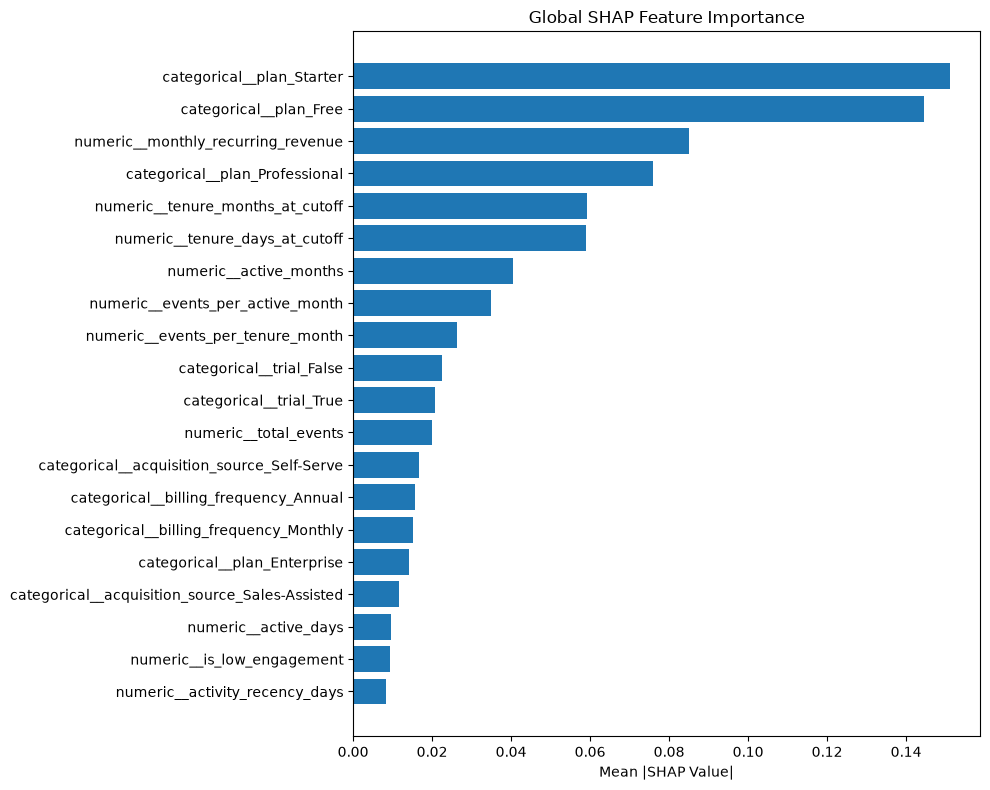

In [23]:
if shap_available:

    top_shap = (
        shap_importance
        .head(20)
        .sort_values(
            "mean_abs_shap"
        )
    )

    plt.figure(
        figsize=(10, 8)
    )

    plt.barh(
        top_shap[
            "feature"
        ],
        top_shap[
            "mean_abs_shap"
        ],
    )

    plt.title(
        "Global SHAP Feature Importance"
    )

    plt.xlabel(
        "Mean |SHAP Value|"
    )

    plt.tight_layout()

    plt.show()

## 17. SHAP Summary Plot

The summary plot combines:

- Feature importance
- Direction of impact
- Customer-level variation

Interpretation:

- Positive SHAP values push predictions toward churn.
- Negative SHAP values push predictions toward retention.

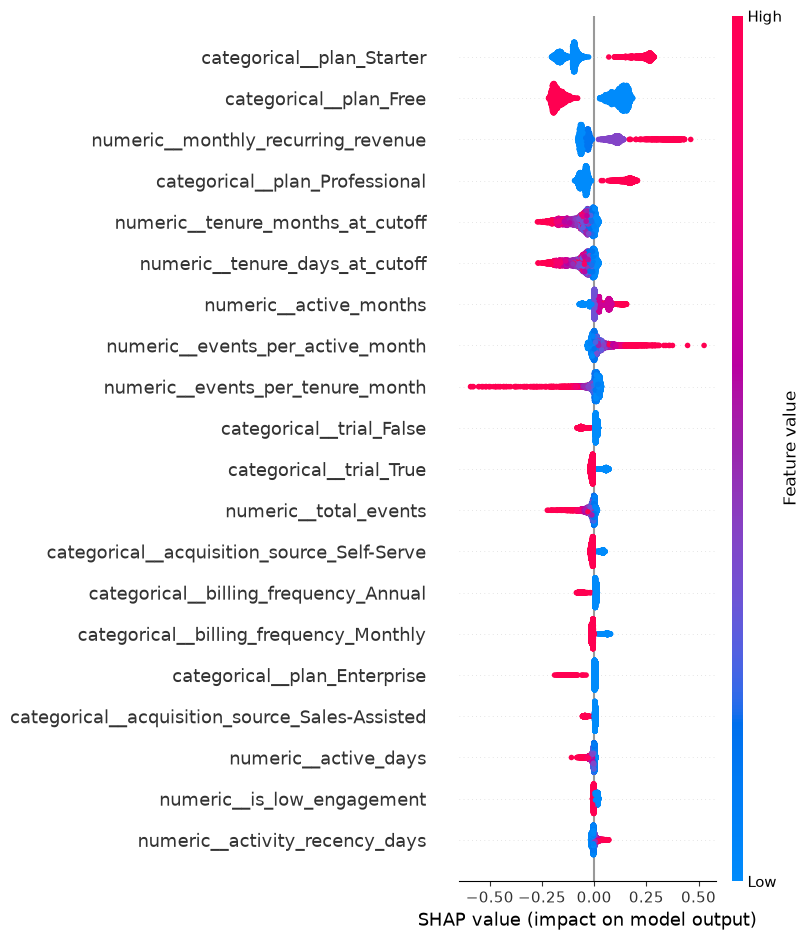

In [24]:
if shap_available:

    shap.summary_plot(
        shap_positive,
        X_shap,
        feature_names=(
            transformed_feature_names
        ),
        show=True,
    )

## 18. Customer-Level Explainability

Global explanations tell us what generally matters.

However, customer-success teams need an individual answer:

> Why is this particular customer considered high risk?

We therefore explain individual high-risk customers.

In [25]:
if risk_scores is not None:

    top_risk_customers = (
        risk_scores
        .sort_values(
            "churn_probability",
            ascending=False,
        )
        .head(10)
        .copy()
    )

    display(
        top_risk_customers
    )

,user_id,cutoff_date,plan,billing_frequency,monthly_recurring_revenue,churn_probability,predicted_churn,risk_segment,risk_revenue_score
134666,U003816,2026-07-01 13:54:32,Starter,Monthly,29.0000,0.9389,1,Very High,27.2281
121790,U019512,2026-07-01 13:54:32,Starter,Monthly,29.0000,0.9357,1,Very High,27.1364
114615,U013095,2026-06-01 13:54:32,Starter,Monthly,29.0000,0.9277,1,Very High,26.9043
130698,U023625,2026-07-01 13:54:32,Professional,Monthly,79.0000,0.9081,1,Very High,71.7370
108026,U004760,2026-06-01 13:54:32,Starter,Monthly,29.0000,0.8658,1,Very High,25.1096
143942,U009370,2026-07-01 13:54:32,Professional,Monthly,79.0000,0.8642,1,Very High,68.2748
77350,U026332,2026-05-01 13:54:32,Professional,Monthly,79.0000,0.8601,1,Very High,67.9471
143627,U008548,2026-07-01 13:54:32,Professional,Annual,79.0000,0.8576,1,Very High,67.7494
87382,U003202,2026-05-01 13:54:32,Enterprise,Monthly,199.0000,0.8530,1,Very High,169.7462
80886,U022997,2026-05-01 13:54:32,Starter,Monthly,29.0000,0.8516,1,Very High,24.6952


## 19. Match High-Risk Customers to Prediction Data

In [26]:
if risk_scores is not None:

    top_customer = (
        top_risk_customers
        .iloc[0]
    )

    customer_id = (
        top_customer[
            "user_id"
        ]
    )

    customer_cutoff = (
        top_customer[
            "cutoff_date"
        ]
    )

    customer_row = prediction_data[
        (
            prediction_data[
                "user_id"
            ]
            == customer_id
        )
        &
        (
            prediction_data[
                "cutoff_date"
            ]
            == customer_cutoff
        )
    ]

    display(
        customer_row
    )

,user_id,total_events,active_days,active_months,first_activity,last_activity,activity_recency_days,avg_events_per_active_day,cutoff_date,plan,billing_frequency,monthly_recurring_revenue,trial,acquisition_source,tenure_days_at_cutoff,tenure_months_at_cutoff,churn_in_prediction_window,events_per_active_month,events_per_tenure_month,is_recently_active,is_low_engagement
397609,U003816,36,13,2,2026-06-18,2026-07-01,0,2.7692,2026-07-01 13:54:32,Starter,Monthly,29.0000,False,Sales-Assisted,0,0.0000,0,18.0000,NaN,1,0


## 20. Generate Individual SHAP Explanation

We calculate the contribution of every transformed feature for the selected customer.

In [29]:
if (
    shap_available
    and risk_scores is not None
):

    customer_X = customer_row[
        feature_columns
    ].copy()

    customer_transformed = (
        preprocessor.transform(
            customer_X
        )
    )

    # --------------------------------------------------------
    # Calculate SHAP values
    # --------------------------------------------------------

    raw_customer_shap = (
        explainer.shap_values(
            customer_transformed
        )
    )

    # --------------------------------------------------------
    # Normalize SHAP output
    # --------------------------------------------------------

    if isinstance(
        raw_customer_shap,
        list
    ):

        # Binary classification:
        # [class_0_values, class_1_values]

        if len(raw_customer_shap) >= 2:

            customer_shap = (
                np.asarray(
                    raw_customer_shap[1]
                )
            )

        else:

            customer_shap = (
                np.asarray(
                    raw_customer_shap[0]
                )
            )

    elif hasattr(
        raw_customer_shap,
        "values"
    ):

        customer_shap = np.asarray(
            raw_customer_shap.values
        )

    else:

        customer_shap = np.asarray(
            raw_customer_shap
        )

    # --------------------------------------------------------
    # Remove unnecessary dimensions
    # --------------------------------------------------------

    print(
        "Raw SHAP shape:",
        customer_shap.shape
    )

    # Expected possibilities:
    #
    # (1, n_features)
    # (1, n_features, 2)
    # (n_features,)
    #
    # We need:
    #
    # (n_features,)

    if customer_shap.ndim == 3:

        # Binary classification:
        # (samples, features, classes)

        customer_shap = (
            customer_shap[
                0,
                :,
                1
            ]
        )

    elif customer_shap.ndim == 2:

        # Single customer:
        # (1, features)

        customer_shap = (
            customer_shap[
                0,
                :
            ]
        )

    elif customer_shap.ndim == 1:

        # Already correct
        customer_shap = (
            customer_shap
        )

    else:

        raise ValueError(
            "Unexpected SHAP output shape: "
            f"{customer_shap.shape}"
        )

    # --------------------------------------------------------
    # Final validation
    # --------------------------------------------------------

    customer_shap = np.asarray(
        customer_shap
    ).reshape(-1)

    transformed_feature_names = np.asarray(
        transformed_feature_names
    ).reshape(-1)

    print(
        "Final SHAP shape:",
        customer_shap.shape
    )

    print(
        "Feature names shape:",
        transformed_feature_names.shape
    )

    # --------------------------------------------------------
    # Validate dimensions
    # --------------------------------------------------------

    if len(customer_shap) != len(
        transformed_feature_names
    ):

        raise ValueError(
            "SHAP values and feature names "
            "have different lengths.\n"
            f"SHAP values: "
            f"{len(customer_shap)}\n"
            f"Features: "
            f"{len(transformed_feature_names)}"
        )

    # --------------------------------------------------------
    # Create explanation dataframe
    # --------------------------------------------------------

    customer_explanation = pd.DataFrame(
        {
            "feature":
                transformed_feature_names,

            "shap_value":
                customer_shap,
        }
    )

    customer_explanation = (
        customer_explanation
        .sort_values(
            "shap_value",
            ascending=False,
        )
        .reset_index(
            drop=True
        )
    )

    print(
        "\nTop customer-level churn drivers:"
    )

    display(
        customer_explanation.head(15)
    )

Raw SHAP shape: (1, 23, 2)
Final SHAP shape: (23,)
Feature names shape: (23,)

Top customer-level churn drivers:


,feature,shap_value
0,numeric__events_per_active_month,0.3669
1,categorical__plan_Starter,0.2176
2,categorical__plan_Free,0.1958
3,categorical__trial_True,0.0392
4,categorical__acquisition_source_Self-Serve,0.0254
5,numeric__tenure_days_at_cutoff,0.0165
6,numeric__tenure_months_at_cutoff,0.0156
7,numeric__is_low_engagement,0.0124
8,categorical__billing_frequency_Annual,0.0084
9,numeric__events_per_tenure_month,0.0077


## 21. Top Churn Drivers for the Customer

Positive SHAP values indicate factors that increase the model's churn prediction.

Negative SHAP values indicate factors that decrease the model's churn prediction.

In [30]:
if (
    shap_available
    and risk_scores is not None
):

    top_positive = (
        customer_explanation
        .head(10)
    )

    top_negative = (
        customer_explanation
        .tail(10)
        .sort_values(
            "shap_value"
        )
    )

    print(
        "Top factors increasing churn risk:"
    )

    display(
        top_positive
    )

    print(
        "\nTop factors reducing churn risk:"
    )

    display(
        top_negative
    )

Top factors increasing churn risk:


,feature,shap_value
0,numeric__events_per_active_month,0.3669
1,categorical__plan_Starter,0.2176
2,categorical__plan_Free,0.1958
3,categorical__trial_True,0.0392
4,categorical__acquisition_source_Self-Serve,0.0254
5,numeric__tenure_days_at_cutoff,0.0165
6,numeric__tenure_months_at_cutoff,0.0156
7,numeric__is_low_engagement,0.0124
8,categorical__billing_frequency_Annual,0.0084
9,numeric__events_per_tenure_month,0.0077



Top factors reducing churn risk:


,feature,shap_value
22,numeric__total_events,-0.1045
21,numeric__avg_events_per_active_day,-0.0965
20,categorical__plan_Professional,-0.0540
19,categorical__trial_False,-0.0386
18,categorical__acquisition_source_Sales-Assisted,-0.0267
17,numeric__monthly_recurring_revenue,-0.0229
16,numeric__active_days,-0.0168
15,numeric__activity_recency_days,-0.0098
14,categorical__billing_frequency_Monthly,-0.0078
13,numeric__is_recently_active,-0.0017


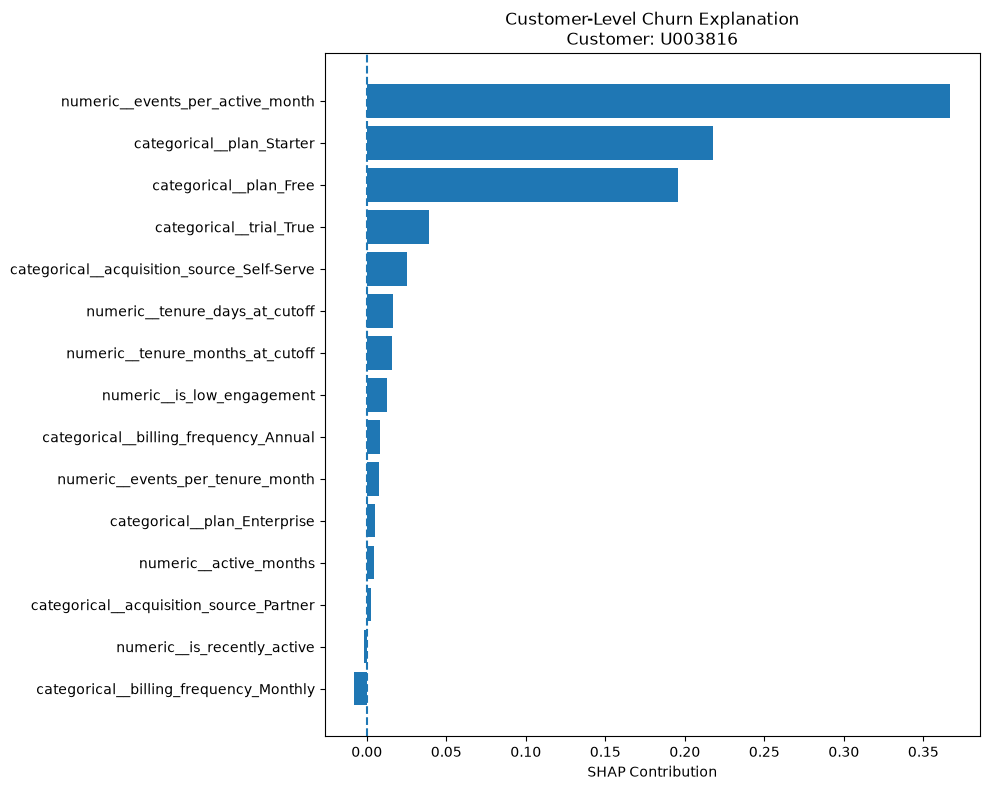

In [31]:
if (
    shap_available
    and risk_scores is not None
):

    explanation_plot = (
        customer_explanation
        .copy()
        .sort_values(
            "shap_value"
        )
        .tail(15)
    )

    plt.figure(
        figsize=(10, 8)
    )

    plt.barh(
        explanation_plot[
            "feature"
        ],
        explanation_plot[
            "shap_value"
        ],
    )

    plt.axvline(
        0,
        linestyle="--",
    )

    plt.title(
        f"Customer-Level Churn Explanation\n"
        f"Customer: {customer_id}"
    )

    plt.xlabel(
        "SHAP Contribution"
    )

    plt.tight_layout()

    plt.show()

## 22. Explain Multiple High-Risk Customers

Instead of explaining only one customer, create a reusable explanation table for the top high-risk customers.

This can later support the Streamlit application.

In [33]:
if (
    shap_available
    and risk_scores is not None
):

    explanation_records = []

    customers_to_explain = (
        top_risk_customers
        .head(20)
    )

    # --------------------------------------------------------
    # Get feature names from the actual preprocessor
    # --------------------------------------------------------

    transformed_feature_names = (
        preprocessor.get_feature_names_out(
            feature_columns
        )
    )

    transformed_feature_names = np.asarray(
        transformed_feature_names
    )

    print(
        "Number of transformed features:",
        len(transformed_feature_names)
    )

    for _, customer in (
        customers_to_explain.iterrows()
    ):

        row = prediction_data[
            (
                prediction_data["user_id"]
                == customer["user_id"]
            )
            &
            (
                prediction_data["cutoff_date"]
                == customer["cutoff_date"]
            )
        ]

        if len(row) == 0:
            continue

        # ----------------------------------------------------
        # Transform customer data
        # ----------------------------------------------------

        customer_transformed = (
            preprocessor.transform(
                row[feature_columns]
            )
        )

        # ----------------------------------------------------
        # Calculate SHAP values
        # ----------------------------------------------------

        if hasattr(
            estimator,
            "feature_importances_"
        ):

            values = (
                explainer.shap_values(
                    customer_transformed
                )
            )

            # Older SHAP classification output
            if isinstance(values, list):

                if len(values) > 1:
                    values = values[1]
                else:
                    values = values[0]

            # SHAP Explanation object
            elif hasattr(values, "values"):

                values = values.values

        else:

            values = (
                explainer(
                    customer_transformed
                ).values
            )

        # ----------------------------------------------------
        # Normalize SHAP shape
        # ----------------------------------------------------

        values = np.asarray(values)

        if values.ndim == 3:

            # (samples, features, classes)
            values = values[:, :, 1]

        elif values.ndim == 2:

            # (samples, features)
            pass

        elif values.ndim == 1:

            # (features,)
            values = values.reshape(
                1,
                -1
            )

        else:

            raise ValueError(
                f"Unexpected SHAP shape: {values.shape}"
            )

        # ----------------------------------------------------
        # Single customer
        # ----------------------------------------------------

        values = values[0]

        # ----------------------------------------------------
        # Safety check
        # ----------------------------------------------------

        if len(values) != len(
            transformed_feature_names
        ):

            raise ValueError(
                "SHAP feature mismatch: "
                f"{len(values)} SHAP values vs "
                f"{len(transformed_feature_names)} "
                "feature names."
            )

        # ----------------------------------------------------
        # Top 5 most influential features
        # ----------------------------------------------------

        top_index = np.argsort(
            np.abs(values)
        )[-5:][::-1]

        for index in top_index:

            explanation_records.append(
                {
                    "user_id":
                        customer["user_id"],

                    "cutoff_date":
                        customer["cutoff_date"],

                    "churn_probability":
                        customer[
                            "churn_probability"
                        ],

                    "feature":
                        transformed_feature_names[
                            index
                        ],

                    "shap_value":
                        values[index],

                    "direction":
                        (
                            "Increases churn risk"
                            if values[index] > 0
                            else
                            "Reduces churn risk"
                        ),
                }
            )

    # --------------------------------------------------------
    # Create explanation DataFrame
    # --------------------------------------------------------

    high_risk_explanations = pd.DataFrame(
        explanation_records
    )

    display(
        high_risk_explanations.head(30)
    )

Number of transformed features: 23


,user_id,cutoff_date,churn_probability,feature,shap_value,direction
0,U003816,2026-07-01 13:54:32,0.9389,numeric__events_per_active_month,0.3472,Increases churn risk
1,U003816,2026-07-01 13:54:32,0.9389,categorical__plan_Starter,0.2405,Increases churn risk
2,U003816,2026-07-01 13:54:32,0.9389,categorical__plan_Free,0.2001,Increases churn risk
3,U003816,2026-07-01 13:54:32,0.9389,numeric__avg_events_per_active_day,-0.1088,Reduces churn risk
4,U003816,2026-07-01 13:54:32,0.9389,numeric__total_events,-0.1077,Reduces churn risk
5,U019512,2026-07-01 13:54:32,0.9357,numeric__events_per_active_month,0.3158,Increases churn risk
6,U019512,2026-07-01 13:54:32,0.9357,categorical__plan_Starter,0.2349,Increases churn risk
7,U019512,2026-07-01 13:54:32,0.9357,categorical__plan_Free,0.1938,Increases churn risk
8,U019512,2026-07-01 13:54:32,0.9357,numeric__total_events,-0.0913,Reduces churn risk
9,U019512,2026-07-01 13:54:32,0.9357,numeric__avg_events_per_active_day,-0.0842,Reduces churn risk


## 23. Business Interpretation of Explainability

The model should not be interpreted as a causal system.

For example:

If `activity_recency_days` has a strong positive SHAP contribution, the appropriate interpretation is:

> Customers who have been inactive for longer periods tend to receive higher predicted churn probabilities.

It should **not** automatically be interpreted as:

> Reducing inactivity will definitely prevent churn.

That would require causal experimentation.

### Potential Business Actions

| Model Signal | Potential Action |
|---|---|
| High activity recency | Re-engagement campaign |
| Low event volume | Product adoption campaign |
| Low active days | Customer-success outreach |
| Short tenure | Improve onboarding |
| High-value customer + high risk | Priority retention intervention |
| Trial + high risk | Trial conversion campaign |

## 24. Revenue-Weighted Churn Risk

Prediction probability alone is not enough for business prioritization.

A customer with:

- 90% churn probability
- $20 MRR

may be less commercially important than:

- 70% churn probability
- $1,000 MRR

Therefore we combine:

**Churn Probability × Monthly Recurring Revenue**

to estimate a simple risk-value score.

In [37]:
if risk_scores is not None:

    priority = risk_scores.copy()

    priority[
        "risk_value"
    ] = (
        priority[
            "churn_probability"
        ]
        *
        priority[
            "monthly_recurring_revenue"
        ].fillna(0)
    )

    priority = (
        priority
        .sort_values(
            "risk_value",
            ascending=False,
        )
    )

    display(
        priority[
            [
                "user_id",
                "plan",
                "monthly_recurring_revenue",
                "churn_probability",
                "risk_value",
                "risk_segment",
            ]
        ].head(25)
    )

,user_id,plan,monthly_recurring_revenue,churn_probability,risk_value,risk_segment
87382,U003202,Enterprise,199.0000,0.8530,169.7462,Very High
94627,U010195,Enterprise,199.0000,0.7850,156.2110,Very High
75236,U018615,Enterprise,199.0000,0.7751,154.2511,Very High
13189,U007504,Enterprise,199.0000,0.7586,150.9672,Very High
106955,U024697,Enterprise,199.0000,0.7289,145.0488,High
121819,U019652,Enterprise,199.0000,0.7202,143.3164,High
62616,U001880,Enterprise,199.0000,0.7139,142.0700,High
54454,U028564,Enterprise,199.0000,0.7046,140.2118,High
90710,U014265,Enterprise,199.0000,0.7020,139.6912,High
7262,U029131,Enterprise,199.0000,0.6972,138.7490,High


## 25. High-Risk Revenue Exposure

Estimate how much recurring revenue belongs to customers classified as high risk.

This provides an executive-level view of potential revenue exposure.

In [38]:
if risk_scores is not None:

    total_mrr = (
        risk_scores[
            "monthly_recurring_revenue"
        ]
        .fillna(0)
        .sum()
    )

    high_risk = risk_scores[
        risk_scores[
            "risk_segment"
        ].isin(
            [
                "High",
                "Very High",
            ]
        )
    ]

    high_risk_mrr = (
        high_risk[
            "monthly_recurring_revenue"
        ]
        .fillna(0)
        .sum()
    )

    high_risk_revenue_pct = (
        high_risk_mrr
        / total_mrr
        * 100
        if total_mrr > 0
        else 0
    )

    print(
        f"Total MRR in test customers: "
        f"${total_mrr:,.2f}"
    )

    print(
        f"High-risk MRR: "
        f"${high_risk_mrr:,.2f}"
    )

    print(
        f"High-risk MRR exposure: "
        f"{high_risk_revenue_pct:.2f}%"
    )

Total MRR in test customers: $6,259,386.00
High-risk MRR: $2,029,229.00
High-risk MRR exposure: 32.42%


## 26. Save Explainability Outputs

In [39]:
if global_importance is not None:

    global_importance.to_csv(
        ANALYTICS_DIR
        / "model_global_importance.csv",
        index=False,
    )

if shap_available:

    shap_importance.to_csv(
        ANALYTICS_DIR
        / "model_shap_importance.csv",
        index=False,
    )

if (
    shap_available
    and risk_scores is not None
):

    high_risk_explanations.to_csv(
        ANALYTICS_DIR
        / "high_risk_customer_explanations.csv",
        index=False,
    )

if risk_scores is not None:

    priority.to_csv(
        ANALYTICS_DIR
        / "churn_priority_customers.csv",
        index=False,
    )

print(
    "Explainability outputs saved."
)

Explainability outputs saved.


## 27. Executive Explainability Summary

In [40]:
print("=" * 75)
print("CHURN MODEL EXPLAINABILITY — EXECUTIVE SUMMARY")
print("=" * 75)

print(
    f"Model: {type(estimator).__name__}"
)

if global_importance is not None:

    print(
        "\nTop global model drivers:"
    )

    for feature in (
        global_importance
        .head(5)["feature"]
    ):

        print(
            f"- {feature}"
        )

if shap_available:

    print(
        "\nTop SHAP drivers:"
    )

    for feature in (
        shap_importance
        .head(5)["feature"]
    ):

        print(
            f"- {feature}"
        )

if risk_scores is not None:

    print(
        "\nHighest-risk customers:"
    )

    display(
        risk_scores[
            [
                "user_id",
                "churn_probability",
                "risk_segment",
            ]
        ]
        .sort_values(
            "churn_probability",
            ascending=False,
        )
        .head(10)
    )

print("=" * 75)

CHURN MODEL EXPLAINABILITY — EXECUTIVE SUMMARY
Model: LogisticRegression

Top SHAP drivers:
- categorical__plan_Starter
- categorical__plan_Free
- numeric__monthly_recurring_revenue
- categorical__plan_Professional
- numeric__tenure_months_at_cutoff

Highest-risk customers:


,user_id,churn_probability,risk_segment
134666,U003816,0.9389,Very High
121790,U019512,0.9357,Very High
114615,U013095,0.9277,Very High
130698,U023625,0.9081,Very High
108026,U004760,0.8658,Very High
143942,U009370,0.8642,Very High
77350,U026332,0.8601,Very High
143627,U008548,0.8576,Very High
87382,U003202,0.8530,Very High
80886,U022997,0.8516,Very High


# Conclusion

This notebook makes the churn prediction model interpretable.

## Completed

- Loaded the production-style churn model
- Inspected model architecture
- Calculated global feature importance
- Added SHAP-based explainability
- Generated global SHAP importance
- Generated SHAP summary analysis
- Explained individual high-risk customers
- Identified positive and negative churn drivers
- Created high-risk customer explanations
- Combined churn probability with MRR
- Estimated high-risk revenue exposure
- Saved explainability datasets

## Business Outcome

The project can now answer three levels of questions:

### Descriptive

**What happened?**

Customer behavior, retention, revenue, funnel and churn analysis.

### Predictive

**What is likely to happen?**

Predict which customers are likely to churn.

### Explainable

**Why is it likely to happen?**

Identify the behavioral and commercial factors associated with each churn prediction.

This makes the project significantly more useful for SaaS product, customer-success, revenue, and management teams.

---

## Next Stage

The core analytics and machine-learning notebooks are now complete.

The next stage is the **application layer**:

`app/`

and the Streamlit dashboard.

The dashboard will bring together:

- Executive KPIs
- Product usage
- Funnel
- Retention
- Revenue
- Churn
- Churn prediction
- Customer risk
- Model explanations